In [1]:
# CELL 1: Import libraries and load dataset
# Purpose: Load the dataset and view basic information

import pandas as pd
import numpy as np

df = pd.read_csv("Final_SP_dataSet.csv")   # if file is in same folder


print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1099, 12)


,Age,Gender,Stress Level,Academic Performance,Health Condition,Relationship Condition,Family Problem,Depression Level,Anxiety Level,Mental Support,Self Harm Story,Suicide Attempt
0,22,Female,Low,Good,Normal,In a relationship,NaN,Always,Always,Family,No,Never Thought
1,23,Male,High,Good,Fair,Single,NaN,Always,Often,loneliness,Yes,Attempted
2,19,Female,Moderate,Poor,Normal,Breakup,Parental conflict,Often,Often,Friends,Yes,Thought
3,18,Female,High,Average,Abnormal,Single,Financial,Always,Often,loneliness,Yes,Thought
4,19,Female,Low,Good,Fair,Single,NaN,Sometimes,Sometimes,Family,No,Never Thought


In [2]:
# CELL 2: Check and remove duplicate rows
# Purpose: Find duplicate rows and remove them

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 45
Shape after removing duplicates: (1054, 12)


In [3]:
# CELL 3: Check missing (null) values
# Purpose: See how many missing values are in each column

missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values)


Missing values per column:

Age                         0
Gender                      0
Stress Level                0
Academic Performance        0
Health Condition            0
Relationship Condition      0
Family Problem            379
Depression Level            0
Anxiety Level               0
Mental Support              0
Self Harm Story             0
Suicide Attempt             0
dtype: int64


In [4]:
# CELL 4: Handle missing values
# Purpose: Fill missing values in "Family Problem" with a category name

df["Family Problem"] = df["Family Problem"].fillna("None")

print("Missing values after filling:\n")
print(df.isnull().sum())


Missing values after filling:

Age                       0
Gender                    0
Stress Level              0
Academic Performance      0
Health Condition          0
Relationship Condition    0
Family Problem            0
Depression Level          0
Anxiety Level             0
Mental Support            0
Self Harm Story           0
Suicide Attempt           0
dtype: int64


In [5]:
# CELL 5: Basic text cleaning for categorical columns
# Purpose: Remove extra spaces (helps avoid duplicate categories like "Good " vs "Good")

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Text columns cleaned successfully.")


Text columns cleaned successfully.


In [6]:
# CELL 6: Final check after preprocessing
# Purpose: Confirm dataset is clean and ready for EDA

print("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (1054, 12)


,Age,Gender,Stress Level,Academic Performance,Health Condition,Relationship Condition,Family Problem,Depression Level,Anxiety Level,Mental Support,Self Harm Story,Suicide Attempt
0,22,Female,Low,Good,Normal,In a relationship,None,Always,Always,Family,No,Never Thought
1,23,Male,High,Good,Fair,Single,None,Always,Often,loneliness,Yes,Attempted
2,19,Female,Moderate,Poor,Normal,Breakup,Parental conflict,Often,Often,Friends,Yes,Thought
3,18,Female,High,Average,Abnormal,Single,Financial,Always,Often,loneliness,Yes,Thought
4,19,Female,Low,Good,Fair,Single,None,Sometimes,Sometimes,Family,No,Never Thought


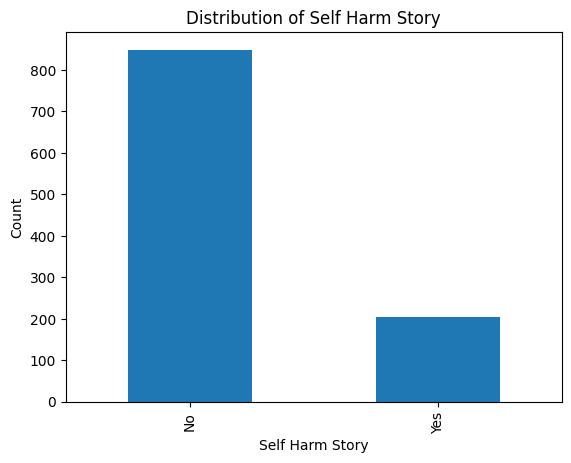

In [7]:
# CELL 1: Distribution of Self Harm Story (Target Variable)
# Purpose: Understand class distribution

import matplotlib.pyplot as plt

df["Self Harm Story"].value_counts().plot(kind="bar")
plt.title("Distribution of Self Harm Story")
plt.xlabel("Self Harm Story")
plt.ylabel("Count")
plt.show()


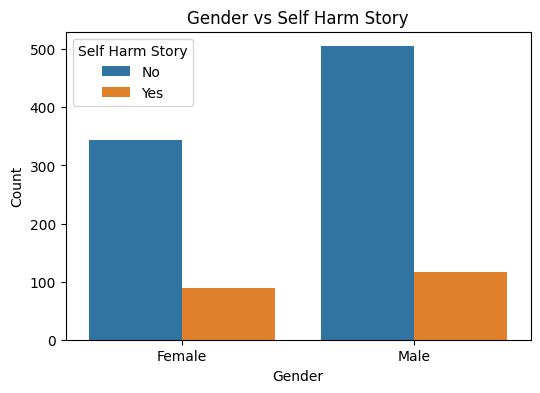

In [8]:
# CELL 2: Gender vs Self Harm Story
# Purpose: Check if self-harm differs by gender

import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Self Harm Story")
plt.title("Gender vs Self Harm Story")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


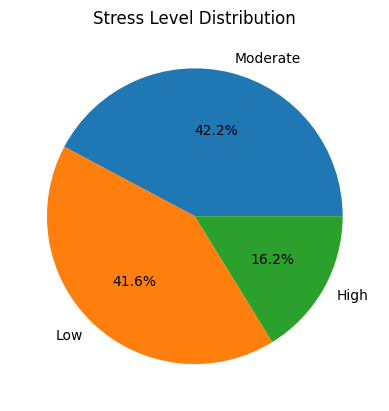

In [9]:
# CELL 3: Stress Level distribution
# Purpose: Understand stress levels among students

df["Stress Level"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Stress Level Distribution")
plt.ylabel("")
plt.show()


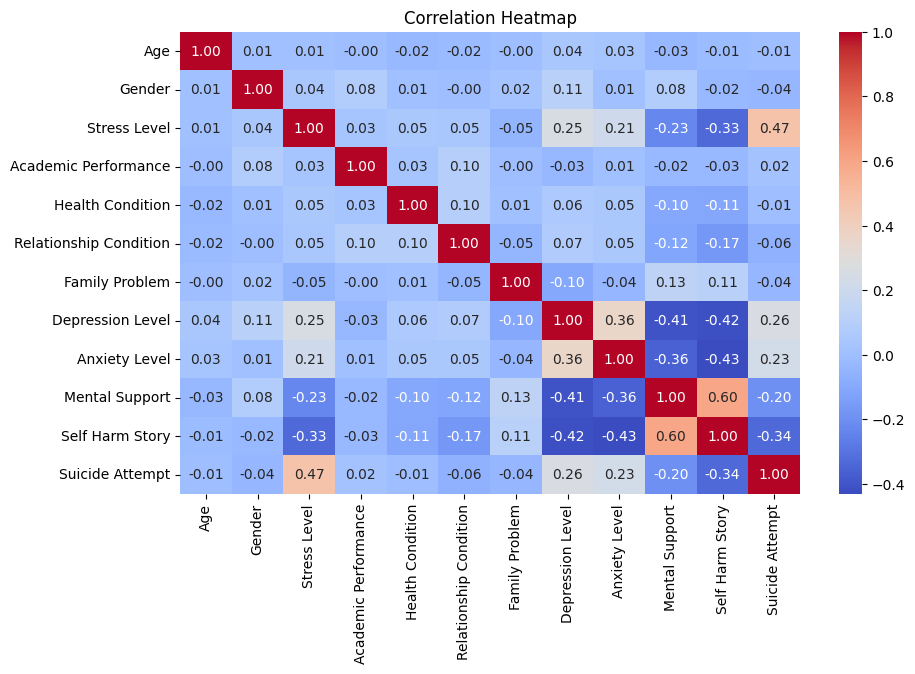

In [10]:
# CELL 5: Correlation Heatmap (Encoded Data)
# Purpose: Identify relationships between key variables

from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode categorical columns
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col])

# Correlation matrix
corr = df_encoded.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [11]:
# CELL 1: Separate features (X) and target (y)
# Purpose: Define input features and target variable

X = df.drop("Self Harm Story", axis=1)
y = df["Self Harm Story"]


In [12]:
# CELL 2: Label Encoding categorical variables
# Purpose: Convert text categories into numeric values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = le.fit_transform(X[col])

# Encode target variable
y = le.fit_transform(y)

print("Label encoding completed.")


Label encoding completed.


In [13]:
# CELL 3: Train-Test Split
# Purpose: Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (843, 11)
Testing set shape: (211, 11)


In [14]:
# CELL 4: Standard Scaling
# Purpose: Scale numerical features for better model performance

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standard scaling applied.")


Standard scaling applied.


In [15]:
# CELL 5: Apply SMOTE on training data only
# Purpose: Handle class imbalance in training dataset

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:", y_train.shape)
print("After SMOTE:", y_train_smote.shape)


Before SMOTE: (843,)
After SMOTE: (1358,)


In [16]:
# CELL 1: Naive Bayes Model
# Purpose: Train and evaluate Naive Bayes with clear parameters

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Naive Bayes parameters:
# var_smoothing: adds stability when variance is very small
nb_model = GaussianNB(var_smoothing=1e-9)

nb_model.fit(X_train_smote, y_train_smote)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9052132701421801
Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       170
           1       0.68      0.95      0.80        41

    accuracy                           0.91       211
   macro avg       0.84      0.92      0.87       211
weighted avg       0.93      0.91      0.91       211

Confusion Matrix:
 [[152  18]
 [  2  39]]


In [17]:
# CELL 2: Support Vector Machine (SVM)
# Purpose: Train and evaluate SVM with defined hyperparameters

from sklearn.svm import SVC

# SVM parameters:
# kernel='rbf' : handles non-linear relationships
# C=1.0        : regularization parameter
# gamma='scale': controls influence of single training points
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8957345971563981
SVM Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       170
           1       0.67      0.90      0.77        41

    accuracy                           0.90       211
   macro avg       0.82      0.90      0.85       211
weighted avg       0.92      0.90      0.90       211

Confusion Matrix:
 [[152  18]
 [  4  37]]


In [18]:
# CELL 3: Random Forest Classifier
# Purpose: Train and evaluate Random Forest with clear parameters

from sklearn.ensemble import RandomForestClassifier

# Random Forest parameters:
# n_estimators=200 : number of trees
# max_depth=10     : limits tree depth to reduce overfitting
# min_samples_split=5 : minimum samples to split a node
# min_samples_leaf=2  : minimum samples at leaf node
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.919431279620853
Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       170
           1       0.76      0.85      0.80        41

    accuracy                           0.92       211
   macro avg       0.86      0.89      0.88       211
weighted avg       0.92      0.92      0.92       211

Confusion Matrix:
 [[159  11]
 [  6  35]]


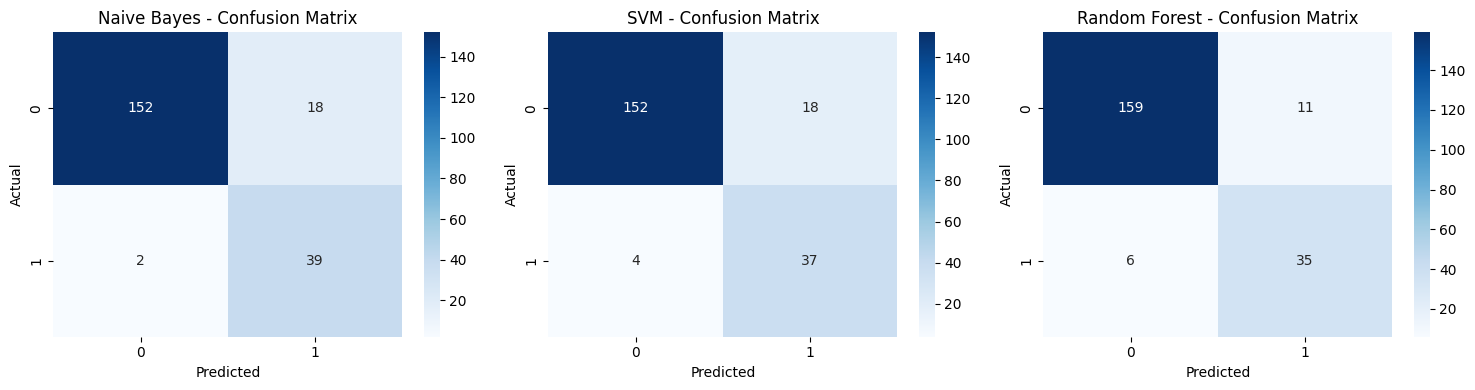

In [19]:
# CELL 1: Confusion Matrix plots for all 3 models
# Purpose: Visualize confusion matrix for each model

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_preds = {
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

plt.figure(figsize=(15,4))

i = 1
for name, pred in models_preds.items():
    cm = confusion_matrix(y_test, pred)

    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    i += 1

plt.tight_layout()
plt.show()


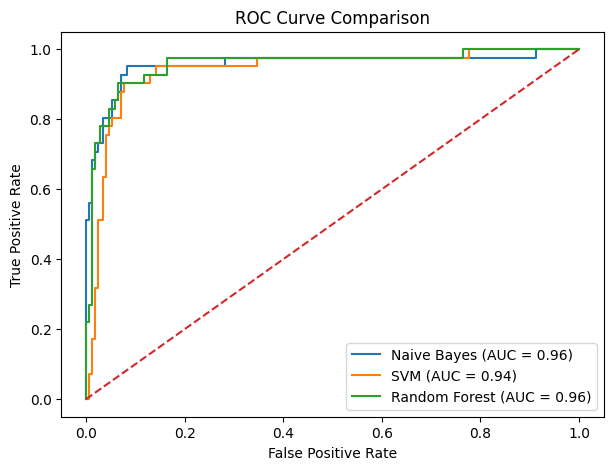

In [20]:
# CELL 2: ROC Curve + AUC for all 3 models (Binary Classification)
# Purpose: Compare ROC curves and AUC scores

from sklearn.metrics import roc_curve, roc_auc_score

# NOTE: For SVM ROC, ensure you trained with probability=True:
# svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)

# Get probability scores for class "1"
nb_probs = nb_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# AUC scores
auc_nb = roc_auc_score(y_test, nb_probs)
auc_svm = roc_auc_score(y_test, svm_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(7,5))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# diagonal line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


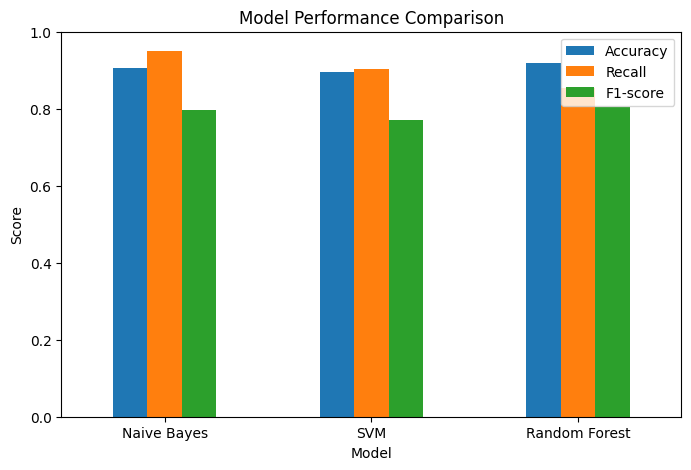

           Model  Accuracy    Recall  F1-score
0    Naive Bayes  0.905213  0.951220  0.795918
1            SVM  0.895735  0.902439  0.770833
2  Random Forest  0.919431  0.853659  0.804598


In [21]:
# CELL 3: Comparison Plot (Accuracy, Recall, F1-score)
# Purpose: Compare model performance in one chart

from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ]
})

# Plot comparison
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

print(results)


In [22]:
# CELL 1: RandomizedSearchCV - Naive Bayes (GaussianNB)
# Purpose: Tune Naive Bayes and print best parameters + classification report

import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", GaussianNB())
])

# Random search space (reasonable and not too small)
nb_param_dist = {
    "model__var_smoothing": np.logspace(-12, -6, 30)
}

nb_random = RandomizedSearchCV(
    estimator=nb_pipe,
    param_distributions=nb_param_dist,
    n_iter=20,              # not too less, still fast
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

nb_random.fit(X_train, y_train)

print("Best Naive Bayes Params:", nb_random.best_params_)
print("Best Naive Bayes CV F1:", nb_random.best_score_)

y_pred_nb_best = nb_random.predict(X_test)
print("\nNaive Bayes (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred_nb_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_best))


Best Naive Bayes Params: {'model__var_smoothing': np.float64(3.856620421163472e-07)}
Best Naive Bayes CV F1: 0.7188781884067152

Naive Bayes (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       170
           1       0.68      0.95      0.80        41

    accuracy                           0.91       211
   macro avg       0.84      0.92      0.87       211
weighted avg       0.93      0.91      0.91       211

Confusion Matrix:
 [[152  18]
 [  2  39]]


In [23]:
# CELL 2: RandomizedSearchCV - SVM (SVC)
# Purpose: Tune SVM and print best parameters + classification report
# NOTE: SVM tuning is slow, so this setup is balanced (good search but manageable runtime)

from sklearn.svm import SVC

svm_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(probability=True, random_state=42))
])

# Balanced search space (not too small, but avoids heavy kernels)
svm_param_dist = {
    "model__kernel": ["rbf"],
    "model__C": np.logspace(-2, 2, 25),        # 0.01 to 100
    "model__gamma": np.logspace(-3, 0, 25)     # 0.001 to 1
}

svm_random = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=svm_param_dist,
    n_iter=25,              # good tuning level, still faster than grid
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

svm_random.fit(X_train, y_train)

print("Best SVM Params:", svm_random.best_params_)
print("Best SVM CV F1:", svm_random.best_score_)

y_pred_svm_best = svm_random.predict(X_test)
print("\nSVM (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred_svm_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_best))


Best SVM Params: {'model__kernel': 'rbf', 'model__gamma': np.float64(0.07498942093324558), 'model__C': np.float64(0.03162277660168379)}
Best SVM CV F1: 0.776347119844339

SVM (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.95       170
           1       0.72      0.93      0.81        41

    accuracy                           0.91       211
   macro avg       0.85      0.92      0.88       211
weighted avg       0.93      0.91      0.92       211

Confusion Matrix:
 [[155  15]
 [  3  38]]


In [24]:
# CELL 3: RandomizedSearchCV - Random Forest
# Purpose: Tune Random Forest and print best parameters + classification report

from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),  # not required for RF but kept consistent
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=30,              # strong tuning but still manageable
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Random Forest Params:", rf_random.best_params_)
print("Best Random Forest CV F1:", rf_random.best_score_)

y_pred_rf_best = rf_random.predict(X_test)
print("\nRandom Forest (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred_rf_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_best))


Best Random Forest Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Best Random Forest CV F1: 0.784602670990741

Random Forest (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.92      0.95       170
           1       0.73      0.90      0.80        41

    accuracy                           0.91       211
   macro avg       0.85      0.91      0.87       211
weighted avg       0.93      0.91      0.92       211

Confusion Matrix:
 [[156  14]
 [  4  37]]


In [25]:
# CELL 3: RandomizedSearchCV - Random Forest
# Purpose: Tune Random Forest and print best parameters + classification report

from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),  # not required for RF but kept consistent
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Random Forest Params:", rf_random.best_params_)
print("Best Random Forest CV F1:", rf_random.best_score_)

y_pred_rf_best = rf_random.predict(X_test)
print("\nRandom Forest (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred_rf_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_best))


Best Random Forest Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Best Random Forest CV F1: 0.784602670990741

Random Forest (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.92      0.95       170
           1       0.73      0.90      0.80        41

    accuracy                           0.91       211
   macro avg       0.85      0.91      0.87       211
weighted avg       0.93      0.91      0.92       211

Confusion Matrix:
 [[156  14]
 [  4  37]]
